# Quantum simulation del dimero: evoluzione temporale con Suzuki-Trotter

Simulazione dell'evoluzione $e^{-iHt}$ del dimero di spin-1/2 su circuito quantistico,
con misura di $S_z$ totale.

**Specifiche concordate**

- 2 qubit (i due spin fisici), nessun qubit ausiliario
- termine DM acceso fin da subito ($D\neq0$)
- osservabile: $S_z$ totale
- stato iniziale: $|00\rangle$
- decomposizione di Suzuki-Trotter al prim'ordine
- parametri da cercare con la dinamica esatta, in modo da ottenere oscillazioni di
  $S_z$ **non banali (non monocromatiche)**

**Hamiltoniana**

$$H = \underbrace{b(s_{z1}+s_{z2}) + J\,\vec s_1\cdot\vec s_2}_{H_1} + \underbrace{D(s_{x1}s_{z2}-s_{z1}s_{x2})}_{H_2}$$

$H_1$ raccoglie campo e scambio isotropo, $H_2$ il solo termine di
Dzyaloshinskii-Moriya. In generale $[H_1,H_2]\neq0$, da cui la necessità di Trotter.

**Convenzione.** Spin 1 $\to$ qubit 0, spin 2 $\to$ qubit 1. Le stringhe di Pauli in
Qiskit sono little-endian: in `Pauli('AB')` l'operatore $B$ agisce sul qubit 0, quindi
$X_1Z_2\equiv$ `Pauli('ZX')`. Con $s_i^\alpha=\sigma_i^\alpha/2$:

$$H_1=\frac b2(Z_1+Z_2)+\frac J4(XX+YY+ZZ),\qquad H_2=\frac D4(X_1Z_2-Z_1X_2)$$

## 1. Impostazione

In [1]:
import json, os
import numpy as np
import scipy.linalg as sla
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Pauli, Operator, Statevector
from qiskit_aer import AerSimulator
from IPython.display import display, Image, clear_output
import io

P = lambda s: Pauli(s).to_matrix()
SZ_TOT = (P('IZ') + P('ZI')) / 2
PSI0 = np.array([1, 0, 0, 0], dtype=complex)          # |00> = |up up>

def H_parts(b, J, D):
    H1 = b/2*(P('IZ')+P('ZI')) + J/4*(P('XX')+P('YY')+P('ZZ'))
    H2 = D/4*(P('ZX') - P('XZ'))                      # X1Z2 - Z1X2
    return H1, H2

def sz(psi):
    return float(np.real(psi.conj() @ SZ_TOT @ psi))

def U_exact(b, J, D, t):
    H1, H2 = H_parts(b, J, D)
    return sla.expm(-1j*(H1+H2)*t)

def U_trotter(b, J, D, t, N):
    # il circuito applica prima H1 e poi H2 -> U_step = e^{-iH2 tau} e^{-iH1 tau}
    H1, H2 = H_parts(b, J, D); tau = t/N
    return np.linalg.matrix_power(sla.expm(-1j*H2*tau) @ sla.expm(-1j*H1*tau), N)

ts = np.linspace(0, 30, 601)

def sz_traj(b, J, D, ts=ts):
    return np.array([sz(U_exact(b, J, D, t) @ PSI0) for t in ts])

def _mostra_figura(fig, out=None, testo=None):
    """Rende la figura come un singolo blob PNG e la mostra con UN SOLO display(),
    in un UNICO ingresso al context 'out'. Bypassa completamente plt.show()/
    l'hook automatico del backend inline (che in alcuni frontend, es. VS Code,
    puo' duplicare il rendering), ed evita di rientrare piu' volte nello stesso
    Output widget nella stessa interazione (altra possibile causa di doppioni).
    out=None -> mostra nella cella corrente."""
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=100, bbox_inches='tight')
    plt.close(fig)
    buf.seek(0)
    img = Image(data=buf.getvalue())
    if out is None:
        clear_output(wait=True)
        display(img)
        if testo: print(testo)
    else:
        with out:
            clear_output(wait=True)
            display(img)
            if testo: print(testo)

## 2. Il termine DM è ciò che rende la dinamica non banale

Prima di cercare i parametri conviene capire cosa può muovere $S_z$. Lo stato iniziale
$|00\rangle=|\!\uparrow\uparrow\rangle$ è il tripletto $|T_{+1}\rangle$: è autostato di
$H_1$ sia del campo ($M=+1$) sia dello scambio isotropo ($S=1$). Quindi per $D=0$

$$e^{-iH_1t}|00\rangle=e^{-i\varphi(t)}|00\rangle\ \Longrightarrow\ \langle S_z\rangle(t)=1\ \ \forall t$$

Il termine DM è antisimmetrico per scambio $1\leftrightarrow2$: accoppia il settore
tripletto (simmetrico) con il singoletto (antisimmetrico) ed è l'unico termine di $H$
che rompe la conservazione di $S_z$. **Senza DM non c'è alcuna dinamica da osservare.**

In [2]:
print("escursione di Sz con D=0   :", np.ptp(sz_traj(1.0, 2.0, 0.0)))
print("escursione di Sz con D=1/3 :", np.ptp(sz_traj(1.0, 2.0, 1/3)))

escursione di Sz con D=0   : 3.008704396734174e-14
escursione di Sz con D=1/3 : 0.006199259177924965


## 3. Il set di partenza $J=2b$, $D=b/3$

Primo tentativo con i valori suggeriti come punto di partenza, cioè $b/J=0.5$ e
$D/J=1/6$.

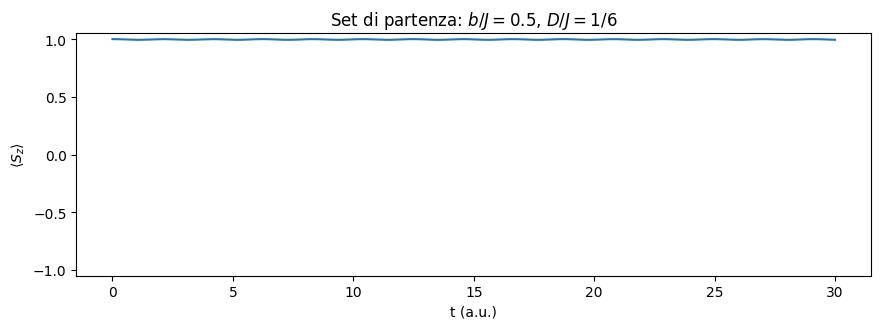

escursione picco-picco = 0.0062
rumore statistico con 8192 shot ~ 1/sqrt(8192) = 0.0110


In [3]:
R0 = dict(b=1.0, J=2.0, D=1/3)
y0 = sz_traj(R0['b'], R0['J'], R0['D'])

fig = plt.figure(figsize=(9, 3.4))
plt.plot(ts, y0, 'C0')
plt.xlabel('t (a.u.)'); plt.ylabel('$\\langle S_z\\rangle$')
plt.title('Set di partenza: $b/J=0.5$, $D/J=1/6$'); plt.ylim(-1.05, 1.05)
plt.tight_layout()
_mostra_figura(fig)

print(f"escursione picco-picco = {np.ptp(y0):.4f}")
print(f"rumore statistico con 8192 shot ~ 1/sqrt(8192) = {1/np.sqrt(8192):.4f}")

Il segnale ha un'escursione di $\sim6\times10^{-3}$, inferiore al rumore statistico di
un campionamento a $8192$ shot: **non è misurabile su circuito**. Serve un altro set di
parametri.

## 4. Ricerca dei parametri con la dinamica esatta

### Criterio

Sviluppando su autostati $H|k\rangle=E_k|k\rangle$, con $|\psi_0\rangle=\sum_kc_k|k\rangle$:

$$\langle S_z\rangle(t)=\underbrace{\sum_k|c_k|^2(S_z)_{kk}}_{\text{costante}}+\sum_{k<l}2\,\mathrm{Re}\!\left[c_k^*c_l(S_z)_{kl}e^{-i\Delta_{kl}t}\right],\qquad \Delta_{kl}=E_l-E_k$$

Il segnale è una somma di modi di frequenza $\Delta_{kl}$ e ampiezza
$a_{kl}=2|c_k^*c_l(S_z)_{kl}|$. Si somma su $k<l$ perché i termini $k=l$ danno solo la
costante e le coppie $(k,l)$, $(l,k)$ descrivono lo stesso modo.

Un set di parametri è accettabile quando soddisfa **entrambe** le condizioni:

1. **escursione** picco-picco di $\langle S_z\rangle$ ben sopra $1/\sqrt{N_{\rm shots}}$;
2. **$a_2/a_1$** vicino a 1, cioè almeno due modi di ampiezza confrontabile — è questo
   che rende l'oscillazione non monocromatica.

Le due condizioni sono in competizione, quindi la ricerca si fa esplorando.

In [4]:
def modi(b, J, D, tol=1e-6):
    # modi spettrali di <Sz>(t): lista di (frequenza, ampiezza), ordinata per ampiezza
    E, V = np.linalg.eigh(sum(H_parts(b, J, D)))
    c = V.conj().T @ PSI0
    S = V.conj().T @ SZ_TOT @ V
    m = {}
    for k in range(4):
        for l in range(k+1, 4):
            a = abs(2*np.real(np.conj(c[k])*c[l]*S[k, l]))
            if a > tol:
                m[round(E[l]-E[k], 3)] = m.get(round(E[l]-E[k], 3), 0) + a
    return sorted(m.items(), key=lambda r: -r[1])

def indicatori(bJ, DJ, J=1.0):
    y = sz_traj(bJ*J, J, DJ*J)
    m = modi(bJ*J, J, DJ*J)
    a1 = m[0][1]
    a2 = m[1][1] if len(m) > 1 else 0.0
    return np.ptp(y), (a2/a1 if a1 > 0 else 0.0), m, y

### Esplorazione interattiva

I due cursori variano $b/J$ e $D/J$ e ridisegnano la dinamica esatta insieme allo
spettro dei modi. Il pulsante **Fissa questi parametri** salva la scelta in
`parametri_scelti.json`: da lì in avanti tutto il notebook usa quei valori, che
restano anche dopo un riavvio del kernel.

Senza `ipywidgets` la stessa esplorazione si fa chiamando `esplora(b/J, D/J)` e
fissando i valori con `fissa_parametri(b/J, D/J)`.

In [5]:
FILE_PARAM = 'parametri_scelti.json'
DEFAULT = dict(b_su_J=-0.18, D_su_J=1.0)

def carica_parametri():
    if os.path.exists(FILE_PARAM):
        with open(FILE_PARAM) as f:
            return json.load(f)
    return dict(DEFAULT)

def fissa_parametri(bJ, DJ):
    p = dict(b_su_J=float(bJ), D_su_J=float(DJ))
    with open(FILE_PARAM, 'w') as f:
        json.dump(p, f, indent=1)
    PARAM.update(p)
    print(f"Parametri fissati e salvati: b/J = {p['b_su_J']:+.3f}, D/J = {p['D_su_J']:.3f}")
    return p

PARAM = carica_parametri()


def esplora(bJ, DJ, shots_rif=8192):
    esc, rap, m, y = indicatori(bJ, DJ)
    fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.6),
                           gridspec_kw={'width_ratios': [2, 1]})

    ax[0].plot(ts, y, 'k', lw=1.4)
    ax[0].axhline(0, color='0.85', lw=0.8, zorder=0)
    ax[0].set_xlabel('t (a.u.)'); ax[0].set_ylabel('$\\langle S_z\\rangle$')
    ax[0].set_ylim(-1.05, 1.05)
    ax[0].set_title(f'$b/J={bJ:+.2f}$,  $D/J={DJ:.2f}$')

    freq = [w for w, _ in m]; amp = [a for _, a in m]
    ax[1].stem(freq, amp, basefmt=' ')
    ax[1].set_xlabel('$\\Delta_{kl}$'); ax[1].set_ylabel('ampiezza $a_{kl}$')
    ax[1].set_xlim(0, max(freq)*1.25 if freq else 1)
    ax[1].set_title('spettro dei modi')
    plt.tight_layout()

    ok_e = "OK " if esc > 5/np.sqrt(shots_rif) else "NO "
    ok_r = "OK " if rap > 0.5 else "NO "
    testo = (f"escursione = {esc:.4f}   {ok_e}(soglia ~ {5/np.sqrt(shots_rif):.4f} = 5x il rumore a {shots_rif} shot)\n"
             f"a2/a1      = {rap:.3f}    {ok_r}(non monocromatico se vicino a 1)\n"
             "modi (frequenza, ampiezza): " + ", ".join(f"({w:.3f}, {a:.3f})" for w, a in m))
    return fig, testo

In [6]:
try:
    import ipywidgets as W
    from IPython.display import display

    s_b = W.FloatSlider(value=PARAM['b_su_J'], min=-1.5, max=0.5, step=0.01,
                        description='b/J:', continuous_update=False, readout_format='.2f')
    s_D = W.FloatSlider(value=PARAM['D_su_J'], min=0.05, max=2.0, step=0.05,
                        description='D/J:', continuous_update=False, readout_format='.2f')
    bottone = W.Button(description='Fissa questi parametri', button_style='success')
    uscita = W.Output()

    _in_corso = [False]   # guardia anti-rientranza: ignora chiamate sovrapposte

    def _render(b_su_J, D_su_J):
        if _in_corso[0]:
            return
        _in_corso[0] = True
        try:
            fig, testo = esplora(b_su_J, D_su_J)
            _mostra_figura(fig, out=uscita, testo=testo)
        finally:
            _in_corso[0] = False

    def _fissa(_):
        with uscita:
            fissa_parametri(s_b.value, s_D.value)

    # interactive_output: il costrutto standard per coordinare piu' widget su un
    # unico Output, con debouncing gestito internamente (a differenza di piu'
    # .observe() separati che chiamano la stessa funzione, un pattern piu' fragile).
    _collegamento = W.interactive_output(_render, {'b_su_J': s_b, 'D_su_J': s_D})
    bottone.on_click(_fissa)
    display(W.VBox([W.HBox([s_b, s_D, bottone]), uscita]))
    _render(s_b.value, s_D.value)

except ImportError:
    print("ipywidgets non disponibile: esplorazione manuale.")
    print("  esplora(-0.18, 1.0)          per provare un set")
    print("  fissa_parametri(-0.18, 1.0)  per fissarlo")
    _fig, _testo = esplora(PARAM['b_su_J'], PARAM['D_su_J'])
    _mostra_figura(_fig, testo=_testo)

### Cosa si osserva muovendo i cursori

- **$D/J$ piccolo** (sotto $\sim0.3$): $|00\rangle$ resta quasi autostato di $H$ e
  l'escursione crolla, come nel set di partenza. Prima condizione non soddisfatta.
- **$b/J\to-1$**: singoletto e $|T_{+1}\rangle$ diventano degeneri, si ottengono
  oscillazioni di Rabi di ampiezza piena ma con $a_2/a_1\to0$, cioè perfettamente
  monocromatiche. Seconda condizione non soddisfatta.
- **$b/J\to0$**: un solo modo domina di nuovo.
- Il compromesso si trova a $|b/J|$ **piccolo ma non nullo** e $D/J$ **dell'ordine
  dell'unità**, dove i due modi principali hanno ampiezze quasi uguali e il segnale
  mostra battimenti evidenti.

## 5. Parametri adottati

Da qui in avanti il notebook usa i valori fissati sopra.

> Se si cambiano i parametri con i cursori e si preme **Fissa questi parametri**,
> occorre rieseguire le celle da questa in poi perché il resto del notebook ne tenga
> conto. Il file `parametri_scelti.json` conserva la scelta anche dopo un riavvio del
> kernel; cancellandolo si torna al valore predefinito.

In [7]:
PARAM = carica_parametri()
J = 1.0
b = PARAM['b_su_J']*J
D = PARAM['D_su_J']*J
esc, rap, m, y_ex = indicatori(PARAM['b_su_J'], PARAM['D_su_J'], J)

print(f"b/J = {PARAM['b_su_J']:+.3f}   D/J = {PARAM['D_su_J']:.3f}")
print(f"escursione = {esc:.4f}   a2/a1 = {rap:.3f}")
print("\nlivelli energetici:", np.round(np.linalg.eigvalsh(sum(H_parts(b, J, D))), 4))
print("modi spettrali:")
for w, a in m:
    print(f"   Delta = {w:7.4f}   ampiezza = {a:.4f}")

b/J = +0.350   D/J = 0.800
escursione = 0.2157   a2/a1 = 0.841

livelli energetici: [-0.9029 -0.0084  0.25    0.6612]
modi spettrali:
   Delta =  0.6700   ampiezza = 0.0586
   Delta =  1.5640   ampiezza = 0.0493
   Delta =  0.8940   ampiezza = 0.0165


## 6. Decomposizione in circuito

Il passo di Trotter separa $e^{-i(H_1+H_2)\tau}\approx e^{-iH_1\tau}e^{-iH_2\tau}$.
I due blocchi sono invece **esatti**:

$$e^{-iH_1\tau}=R_z^{(1)}(b\tau)R_z^{(2)}(b\tau)\,R_{XX}\!\left(\tfrac{J\tau}2\right)R_{YY}\!\left(\tfrac{J\tau}2\right)R_{ZZ}\!\left(\tfrac{J\tau}2\right)$$

perché campo e scambio isotropo commutano ($[S^2,S_z]=0$), e

$$e^{-iH_2\tau}=\Big[(I\otimes H)R_{ZZ}\!\left(-\tfrac{D\tau}2\right)(I\otimes H)\Big]\Big[(H\otimes I)R_{ZZ}\!\left(\tfrac{D\tau}2\right)(H\otimes I)\Big]$$

perché $[X_1Z_2,Z_1X_2]=0$ e $HZH=X$. L'unica approssimazione dello schema è dunque la
separazione fra $H_1$ e $H_2$.

**Scelta implementativa.** Il blocco $R_{ZZ}(\theta)$ è scritto qui esplicitamente
come $\text{CNOT}\cdot R_z(\theta)_{\rm target}\cdot\text{CNOT}$ anziché come gate
nativo `qc.rzz(...)`: le due forme sono identiche (verificato simbolicamente,
$\text{CNOT}(I\otimes Z)\text{CNOT}=Z\otimes Z$, quindi la coniugazione si trasporta
esattamente sull'esponenziale), ed è la stessa decomposizione contenuta nella
`.definition` interna di `RZZGate` in Qiskit. La scelta rende il conteggio di gate
a due qubit riportato più avanti realistico rispetto a un backend a
superconduttori, dove `CNOT` è nativo e `RZZ` no.

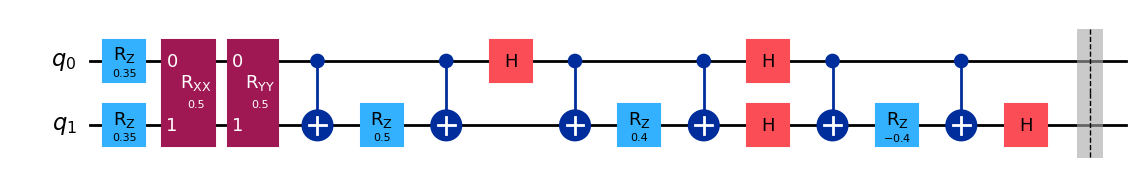

In [8]:
def step_H1(qc, b, J, tau, rappresentazione='cx'):
    qc.rz(b*tau, 0); qc.rz(b*tau, 1)
    qc.rxx(J*tau/2, 0, 1); qc.ryy(J*tau/2, 0, 1)
    if rappresentazione == 'cx':
        qc.cx(0, 1); qc.rz(J*tau/2, 1); qc.cx(0, 1)      # RZZ(J*tau/2) = CNOT-Rz-CNOT
    else:
        qc.rzz(J*tau/2, 0, 1)                             # RZZ(J*tau/2), gate nativo

def step_H2(qc, D, tau, rappresentazione='cx'):
    qc.h(0)                                       # coniuga verso X1Z2
    if rappresentazione == 'cx':
        qc.cx(0, 1); qc.rz( D*tau/2, 1); qc.cx(0, 1)     # RZZ( D*tau/2) = CNOT-Rz-CNOT
    else:
        qc.rzz(D*tau/2, 0, 1)
    qc.h(0)
    qc.h(1)                                       # coniuga verso Z1X2
    if rappresentazione == 'cx':
        qc.cx(0, 1); qc.rz(-D*tau/2, 1); qc.cx(0, 1)     # RZZ(-D*tau/2) = CNOT-Rz-CNOT
    else:
        qc.rzz(-D*tau/2, 0, 1)
    qc.h(1)

def circuito(b, J, D, t, N, misura=False, rappresentazione='cx'):
    # rappresentazione: 'cx' (esplicita, CNOT-Rz-CNOT) oppure 'nativo' (gate RZZGate di Qiskit).
    # Le due danno risultati fisici identici (stessa unita' a scarto zero); cambiano
    # solo conteggio di gate, profondita' e tempo di simulazione classica -- vedi
    # costo_gate_trotter.md per il confronto completo.
    qc = QuantumCircuit(2, 2) if misura else QuantumCircuit(2)
    tau = t/N
    for _ in range(N):
        step_H1(qc, b, J, tau, rappresentazione); step_H2(qc, D, tau, rappresentazione); qc.barrier()
    if misura:
        qc.measure([0, 1], [0, 1])
    return qc

circuito(b, J, D, 1.0, 1).draw('mpl')

### Verifica dei blocchi

Se un blocco non riproduce $e^{-iH_i\tau}$ a $\sim10^{-16}$ significa che c'è un errore
di convenzione (fattori $1/2$ nei gate, segni, ordinamento dei qubit), non un errore di
Trotter. Va controllato prima di guardare qualunque risultato fisico.

In [9]:
tau = 0.37
H1, H2 = H_parts(b, J, D)

qc = QuantumCircuit(2); step_H1(qc, b, J, tau)
print("errore blocco H1 :", np.max(np.abs(Operator(qc).data - sla.expm(-1j*H1*tau))))
qc = QuantumCircuit(2); step_H2(qc, D, tau)
print("errore blocco H2 :", np.max(np.abs(Operator(qc).data - sla.expm(-1j*H2*tau))))
print("circuito completo vs matrice (N=5):",
      np.max(np.abs(Operator(circuito(b, J, D, 2.0, 5)).data - U_trotter(b, J, D, 2.0, 5))))
print("norma di [H1,H2]:", np.linalg.norm(H1@H2 - H2@H1))

errore blocco H1 : 1.1631705747361534e-16
errore blocco H2 : 2.220446049250313e-16
circuito completo vs matrice (N=5): 1.4895204919483639e-15
norma di [H1,H2]: 0.599332962550868


### Switch fra le due rappresentazioni di RZZ

Il parametro `rappresentazione` di `circuito(...)` sceglie fra `'cx'` (esplicita,
usata di default in questo notebook) e `'nativo'` (`RZZGate` di Qiskit). Le due
producono la stessa identica unità — verificato sotto — e cambiano solo conteggio
di gate, profondità e tempo di simulazione classica (dettagli in
`costo_gate_trotter.md`).

In [10]:
for rappr in ['cx', 'nativo']:
    qc_demo = circuito(b, J, D, 30, 20, rappresentazione=rappr)
    ops = qc_demo.count_ops()
    q2 = sum(v for k, v in ops.items() if k in ('rxx', 'ryy', 'cx', 'rzz'))
    print(f"rappresentazione='{rappr}':  gate a 2 qubit = {q2:4d}   profondita' = {qc_demo.depth()}")

U_cx = Operator(circuito(b, J, D, 30, 20, rappresentazione='cx')).data
U_nativo = Operator(circuito(b, J, D, 30, 20, rappresentazione='nativo')).data
print("\nscarto fra le due unita' (N=20):", np.max(np.abs(U_cx - U_nativo)))

rappresentazione='cx':  gate a 2 qubit =  160   profondita' = 300
rappresentazione='nativo':  gate a 2 qubit =  100   profondita' = 180

scarto fra le due unita' (N=20): 0.0


## 7. Convergenza al crescere del numero di passi

L'errore per singolo passo è $O(\tau^2)$: dallo sviluppo di Baker-Campbell-Hausdorff

$$e^{-i(H_1+H_2)\tau}-e^{-iH_1\tau}e^{-iH_2\tau}=\frac{\tau^2}{2}[H_1,H_2]+O(\tau^3)$$

Poiché qui $\tau=t/N$, l'errore accumulato su $N$ passi va come $t^2/N$.

In [11]:
print("  N     max_t |Sz_Trotter - Sz_esatto|      1 - F  a t=30")
psiE30 = U_exact(b, J, D, 30) @ PSI0
for N in [1, 2, 5, 10, 20, 50, 100]:
    yT = np.array([sz(U_trotter(b, J, D, t, N) @ PSI0) for t in ts])
    psiT30 = U_trotter(b, J, D, 30, N) @ PSI0
    print(f"{N:4d}          {np.max(np.abs(yT - y_ex)):.5f}               "
          f"{1-abs(psiE30.conj()@psiT30)**2:.3e}")

  N     max_t |Sz_Trotter - Sz_esatto|      1 - F  a t=30
   1          1.96894               3.047e-01
   2          1.16036               3.574e-01
   5          0.68851               7.551e-01
  10          0.29500               6.785e-01
  20          0.11991               2.371e-01
  50          0.01590               2.944e-02
 100          0.00387               5.923e-03


In [12]:
Ns = np.array([2, 4, 8, 16, 32, 64, 128, 256])

def scaling_errore(t_fix):
    UE = U_exact(b, J, D, t_fix); psiE = UE @ PSI0
    infid = np.array([1 - abs(psiE.conj() @ (U_trotter(b, J, D, t_fix, N) @ PSI0))**2 for N in Ns])
    norme = np.array([np.linalg.norm(UE - U_trotter(b, J, D, t_fix, N), 2) for N in Ns])
    return infid, norme

t_fix = 10.0
infid, norme = scaling_errore(t_fix)
print("pendenza log-log di  1-F    :", round(np.polyfit(np.log(Ns), np.log(infid), 1)[0], 3))
print("pendenza log-log di ||dU||  :", round(np.polyfit(np.log(Ns), np.log(norme), 1)[0], 3),
      "  (atteso -1, primo ordine)")

pendenza log-log di  1-F    : -1.929
pendenza log-log di ||dU||  : -1.075   (atteso -1, primo ordine)


## 8. Esecuzione sul circuito

$S_z=(Z_1+Z_2)/2$ è diagonale nella base computazionale, con autovalori $+1$ su
$|00\rangle$, $-1$ su $|11\rangle$ e $0$ sugli altri due stati. Si stima quindi
direttamente dai conteggi, senza cambio di base:

**Cos'è uno "shot".** Uno shot è una singola esecuzione del circuito seguita da
una misura: preparazione dello stato, evoluzione, e lettura di un solo risultato
binario per esecuzione (es. `00`, `01`, `10` o `11`), non il valore di aspettazione.
La misura quantistica è intrinsecamente probabilistica: per stimare
$\langle S_z\rangle$ serve ripetere l'esperimento molte volte e contare quante volte
esce ciascun risultato — è questo che fa `backend.run(..., shots=8192)`, restituendo
un dizionario di conteggi come `{'00': 4130, '01': 12, '10': 9, '11': 4041}` su 8192
tentativi. $8192=2^{13}$ non ha un significato fisico speciale: è solo un valore di
default comune su simulatori e hardware IBM Quantum.

$$\langle S_z\rangle\simeq\frac{n_{00}-n_{11}}{N_{\rm shots}}$$

In [13]:
N_tr, shots = 20, 8192
ts_sim = np.linspace(0, 30, 31)
backend = AerSimulator()

sv = np.array([sz(np.asarray(Statevector(circuito(b, J, D, t, N_tr)).data)) for t in ts_sim])
sz_shots = []
for t in ts_sim:
    c = backend.run(circuito(b, J, D, t, N_tr, misura=True), shots=shots).result().get_counts()
    sz_shots.append((c.get('00', 0) - c.get('11', 0))/shots)
sz_shots = np.array(sz_shots)

y_ex_sim = sz_traj(b, J, D, ts_sim)
print("max |statevector - esatto| :", np.max(np.abs(sv - y_ex_sim)), " (= errore di Trotter)")
print("RMS |shots - statevector|  :", np.sqrt(np.mean((sz_shots-sv)**2)),
      " atteso ~", 1/np.sqrt(shots))
qc30 = circuito(b, J, D, 30, N_tr)
print("profondita' del circuito a t=30:", qc30.depth(),
      "| gate a 2 qubit:", sum(v for k, v in qc30.count_ops().items() if k in ('rxx', 'ryy', 'cx')))

max |statevector - esatto| : 0.11651243367428565  (= errore di Trotter)
RMS |shots - statevector|  : 0.003697002627018836  atteso ~ 0.011048543456039804
profondita' del circuito a t=30: 300 | gate a 2 qubit: 160


## 9. Risultato complessivo

In [14]:
curve = {N: np.array([sz(U_trotter(b, J, D, t, N) @ PSI0) for t in ts])
         for N in [1, 2, 5, 10, 20, 50, 100]}
colori = {1:'C4', 2:'C3', 5:'C1', 10:'C5', 20:'C2', 50:'C6', 100:'C9'}

# cache dei campionamenti a shot: calcolati al volo per l'N richiesto, una volta sola
_cache_shots = {N_tr: sz_shots}   # il campionamento gia' fatto in Sez.8 e' il primo risultato

def ottieni_shots(N):
    if N not in _cache_shots:
        vals = []
        for t in ts_sim:
            c = backend.run(circuito(b, J, D, t, N, misura=True), shots=shots).result().get_counts()
            vals.append((c.get('00', 0) - c.get('11', 0))/shots)
        _cache_shots[N] = np.array(vals)
    return _cache_shots[N]

def figura(N_mostrati=(2, 5, 20), mostra_esatto=True, mostra_shots=True, t_fix=10.0):
    fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))

    ax[0].plot(ts, y0, 'C0', label='set di partenza')
    ax[0].plot(ts, y_ex, 'k', label=f"adottato: $b/J={PARAM['b_su_J']:+.2f}$, $D/J={PARAM['D_su_J']:.2f}$")
    ax[0].set_xlabel('t (a.u.)'); ax[0].set_ylabel('$\\langle S_z\\rangle$')
    ax[0].set_title('Dinamica esatta: scelta dei parametri'); ax[0].legend(fontsize=8)

    for N in sorted(N_mostrati):
        col = colori.get(N, 'C7')
        ax[1].plot(ts, curve[N], col, lw=1.2, label=f'Trotter N={N}')
        if mostra_shots:
            ax[1].plot(ts_sim, ottieni_shots(N), 'o', color=col, ms=4, mec='k', mew=0.4,
                       label=f'circuito N={N}')
    if mostra_esatto:
        ax[1].plot(ts, y_ex, 'k', lw=2, label='esatto')

    # sottotitolo dinamico: dichiara esplicitamente quale confronto e' attivo
    if mostra_esatto and mostra_shots:
        confronto = 'linea vs nera = errore di Trotter  |  pallini vs linea = rumore di campionamento'
    elif mostra_esatto and not mostra_shots:
        confronto = 'solo errore di Trotter (linea colorata vs esatto)'
    elif mostra_shots and not mostra_esatto:
        confronto = 'solo rumore di campionamento (pallini vs linea dello stesso colore)'
    else:
        confronto = 'nessun confronto attivo (solo curve di Trotter)'

    ax[1].set_xlabel('t (a.u.)'); ax[1].set_ylabel('$\\langle S_z\\rangle$')
    ax[1].set_title(f'Convergenza di Trotter  ({shots} shots per punto)\n{confronto}', fontsize=9)
    ax[1].set_ylim(-1.15, 1.15)
    ax[1].legend(fontsize=7, loc='lower left', ncol=2)

    infid_t, norme_t = scaling_errore(t_fix)
    ax[2].loglog(Ns, infid_t, 'o-', label='$1-\\mathcal{F}$')
    ax[2].loglog(Ns, norme_t, 's-', label='$\\|\\Delta U\\|_2$')
    ax[2].set_xlabel('N (passi di Trotter)'); ax[2].set_title(f"Scaling dell'errore, $t={t_fix:.0f}$")
    ax[2].legend(fontsize=8)
    plt.tight_layout()
    return fig

try:
    import ipywidgets as W

    ctrl_N = W.SelectMultiple(options=list(curve), value=(2, 5, 20), description='Trotter N:')
    ctrl_esatto = W.Checkbox(value=True, description='curva esatta')
    ctrl_shots = W.Checkbox(value=True, description='shots')
    ctrl_t = W.FloatSlider(value=10.0, min=1.0, max=30.0, step=1.0,
                           description='t (pannello 3):', continuous_update=False,
                           style={'description_width': 'initial'})
    uscita_fig = W.Output()

    _in_corso_fig = [False]   # guardia anti-rientranza: ignora chiamate sovrapposte

    def _render_fig(N_mostrati, mostra_esatto, mostra_shots, t_fix):
        if _in_corso_fig[0]:
            return
        _in_corso_fig[0] = True
        try:
            fig = figura(N_mostrati, mostra_esatto, mostra_shots, t_fix)
            _mostra_figura(fig, out=uscita_fig)
        finally:
            _in_corso_fig[0] = False

    # interactive_output: un solo punto di coordinamento fra i quattro controlli,
    # invece di quattro .observe() separati che chiamano la stessa funzione.
    _collegamento_fig = W.interactive_output(_render_fig, {
        'N_mostrati': ctrl_N, 'mostra_esatto': ctrl_esatto,
        'mostra_shots': ctrl_shots, 't_fix': ctrl_t})
    display(W.VBox([ctrl_N, ctrl_esatto, ctrl_shots, ctrl_t, uscita_fig]))
    _render_fig(ctrl_N.value, ctrl_esatto.value, ctrl_shots.value, ctrl_t.value)

except ImportError:
    print("ipywidgets non disponibile: uso la selezione predefinita.")
    print("Per cambiarla, chiamare per es.  figura(N_mostrati=(5, 50), mostra_shots=False, t_fix=20.0)")
    _mostra_figura(figura())

### Cosa rappresentano i tre pannelli, e le unità di misura

**Pannello 1 — "Dinamica esatta: scelta dei parametri".** Confronto fra il set
suggerito dal relatore (curva blu) e il punto adottato (curva nera), calcolati
con la dinamica **esatta** (nessuna approssimazione di Trotter, nessun rumore).
Asse $x$: $t$ (a.u.) — tempo in **unità arbitrarie**: non è secondi, è tempo
nelle stesse unità in cui sono espressi $b,J,D$ (adimensionali nel modello); la
quantità fisicamente significativa è la fase $Jt$, non $t$ da solo. Asse $y$:
$\langle S_z\rangle$ — valore di aspettazione della magnetizzazione lungo $z$,
**adimensionale**, compreso fra $-1$ e $+1$ per costruzione.

**Pannello 2 — "Convergenza di Trotter".** Tre livelli diversi dello stesso
calcolo, sovrapposti per scomporre l'errore totale in due pezzi:

| Curva | Cos'è | Errore che porta |
|---|---|---|
| **esatto** (nera) | $e^{-iHt}$ senza approssimazioni | nessuno — è il riferimento |
| **Trotter N=X** (linea colorata) | Simulazione statevector del circuito approssimato a $N$ passi, **deterministica** | solo errore **algoritmico** (approssimazione di Trotter) |
| **shots N=X** (pallini) | Lo stesso circuito, stesso $N$, eseguito davvero con `AerSimulator` e migliaia di shot | errore algoritmico **+** rumore **statistico** di campionamento |

Non è un caso che "shots" condivida lo stesso $N$ della curva Trotter accanto:
serve a isolare visivamente i due contributi — pallini vs linea dello stesso
colore mostra il rumore di campionamento a parità di $N$; linea colorata vs
curva nera mostra l'errore di Trotter da solo. Stessi assi e stesse unità del
pannello 1.

**Pannello 3 — "Scaling dell'errore".** Concettualmente diverso: non mostra
$\langle S_z\rangle(t)$, ma **come l'errore di Trotter cambia al variare del
numero di passi** $N$, a un tempo fisso $t$ (selezionabile con lo slider).
Asse $x$: $N$ — numero di passi di Trotter, un intero puro (adimensionale),
non una grandezza fisica. Asse $y$ (scala **log-log** su entrambi gli assi):
due quantità diverse, entrambe adimensionali, entrambe misure di "quanto la
simulazione approssimata si discosta da quella esatta":
- $1-\mathcal F$ (cerchi): **infedeltà**, con $\mathcal F=|\langle\psi_{\rm esatto}|\psi_{\rm Trotter}\rangle|^2$
  la fedeltà quantistica fra i due stati — $1$ se coincidono, $0$ se sono
  ortogonali; $1-\mathcal F$ è quindi un numero puro fra $0$ e $1$.
- $\|\Delta U\|_2$ (quadrati): **norma operatoriale** della differenza fra la
  matrice unitaria esatta e quella di Trotter — misura quanto le due evoluzioni
  *complessive* (non un singolo stato) differiscono nel caso peggiore.

La scala log-log non è estetica: entrambe le quantità seguono leggi di potenza
in $N$ ($1-\mathcal F\sim N^{-2}$, $\|\Delta U\|_2\sim N^{-1}$), che diventano
**rette** su questa scala — la pendenza della retta è direttamente l'esponente
della legge, leggibile a occhio invece che dedotta dalla forma della curva.

**Perché il tempo di riferimento del pannello 3 è regolabile.** Il valore
scelto non è arbitrario a caso: a $t$ grande con pochi passi il passo
$\tau=t/N$ diventa troppo largo e si esce dal regime asintotico
$\tau\|H\|\ll1$ in cui la formula di Trotter è valida, e la pendenza misurata
si allontana dai valori teorici $-2$/$-1$. Muovendo lo slider verso $t$
crescenti si vede questo peggioramento dal vivo, invece di doverlo prendere
per buono a parole.

## 10. Osservazioni

**Sulla scelta dei parametri.** Il set di partenza $J=2b$, $D=b/3$ dà un segnale di
$6\times10^{-3}$, sotto il rumore statistico: il termine DM è troppo debole per
spostare $|00\rangle$, che resta quasi autostato. La regione utile richiede $D/J$
dell'ordine dell'unità e $|b/J|$ piccolo ma non nullo — i due estremi ($b/J\to-1$ e
$b/J\to0$) danno entrambi segnali monocromatici, per ragioni opposte.

**Sull'errore di Trotter.** A $N$ basso l'errore non è solo quantitativo: le curve a
$N=2$ e $N=5$ compiono un numero di oscillazioni **diverso** da quello esatto, cioè
descrivono una dinamica qualitativamente sbagliata. Il distacco avviene quando
$\tau=t/N$ si avvicina a $1/\|H\|$. Tutte le curve restano comunque entro
$|\langle S_z\rangle|\le1$: il prodotto di esponenziali è unitario per costruzione, e
la norma è conservata esattamente a ogni $N$.

**Sul confronto fra le due sorgenti d'errore.** Con $8192$ shot lo scarto statistico è
$\sim7\times10^{-3}$, mentre l'errore di Trotter a $N=20$ vale $\sim0.25$: l'errore
dominante è **algoritmico**, non statistico. In questo regime aumentare il numero di
shot non migliora il risultato; serve aumentare $N$.

**Costo.** A $t=30$ servono $N\gtrsim100$ per $1-\mathcal F<10^{-2}$, cioè circa $500$
gate a due qubit. È il punto rilevante in vista dell'estensione con rumore: più passi
riducono l'errore algoritmico ma ne accumulano di più sui gate, e il compromesso fra i
due diventa il problema centrale.